### **Q1.** What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.
### **Answer:**
### Anomaly Detection is the process of identifying data points, events, or observations that deviate significantly from the majority of the data. These unusual patterns, often called outliers, can indicate critical incidents, fraud, errors, or novel phenomena.

### **Types of Anomalies:**

### **1. Point Anomalies:**

### - A single data point that is significantly different from the rest of the dataset.
### - **Example:** A credit card transaction of 100.
### **2. Contextual Anomalies (Conditional Anomalies):**

### - A data point that is anomalous in a specific context but may be normal in another context.
### - **Example:** A temperature of 30°C might be normal in summer but anomalous in winter for a specific location.
### **3. Collective Anomalies:**

### - A collection of data points that together deviate from the expected pattern, even if individual points appear normal.
### - **Example:** A sudden spike in server requests over a short period may indicate a Distributed Denial-of-Service (DDoS) attack.

### **Q2.** Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.
### **Answer:**
### **Approach:**
### 1. Builds random trees to isolate observations. Points that are easier to isolate are considered anomalies.
### 2. Density-based clustering. Points in low-density regions (sparse areas) are considered outliers.
### 3. Measures the local density deviation of a point compared to its neighbors. Points with significantly lower density than neighbors are anomalies.

### **Suitable Use Cases:**
### 1. High-dimensional datasets, fraud detection, network intrusion detection.
### 2. Spatial data, geolocation anomalies, datasets with clusters of varying shapes.
### 3. Detecting anomalies in continuous data, sensor readings, or time-series data.

### **Q3.** What are the key components of a Time Series? Explain each with one example.
### **Answer:**

### A time series is a sequence of data points collected or recorded at successive time intervals. The key components of a time series are:

### **1. Trend:**

### - The long-term movement or direction in the data over time.
### **- Example:** Monthly sales of a store showing a steady increase over several years.
### **2. Seasonality:**

### - Regular, repeating patterns or fluctuations in the data at specific intervals.
### **- Example:** Ice cream sales peaking every summer and dropping in winter.
### **3. Cyclic Component:**

### - Long-term oscillations in the data due to economic or business cycles, not of fixed period like seasonality.
### **- Example:** Stock market indices rising and falling over several years due to economic cycles.
### **4. Irregular/Noise Component:**

### - Random variations in the data that cannot be attributed to trend, seasonality, or cyclic patterns.
### **- Example:** Sudden spikes in website traffic due to a viral social media post.

### **Q4.** Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?
### **Answer:**

### **Stationary Time Series:**
### A time series is said to be stationary if its statistical properties such as mean, variance, and autocorrelation remain constant over time. Stationarity is important because many time series forecasting models (like ARIMA) assume the data is stationary.

### **Testing for Stationarity:**

### **1. Visual Inspection:** Plot the time series to check for trends or changing variance.
### **2. Statistical Tests:**
### **- Augmented Dickey-Fuller (ADF) test:** Null hypothesis states the series is non-stationary; a small p-value (< 0.05) indicates stationarity.
### **- KPSS test:** Null hypothesis states the series is stationary; a small p-value indicates non-stationarity.
### **Transforming Non-Stationary Series:**

### **- Differencing:** Subtract the previous observation from the current observation to remove trends.
### ts_diff = ts - ts.shift(1)

### **Q5.** Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.
### **Answer:**

### **Structure / Components:**
### 1. Uses past values of the series to predict current values. Depends on lagged observations (p).
### 2. Uses past forecast errors to predict current values. Depends on lagged errors (q).
### 3. Combines AR, MA, and differencing (d) to handle non-stationarity.
### 4. Extends ARIMA to include seasonal components (P,D,Q,s) to model repeating patterns.
### 5. Adds external variables (exogenous regressors) to SARIMA to account for external influences.
### **Application / Use Case:**
### 1. Stock prices, sales forecasting where past values influence future values.
### 2. Modeling time series with noise or shocks, e.g., residual errors in production data.
### 3. Forecasting non-stationary data like economic indicators or demand trends.
### 4. Seasonal sales, temperature data, or monthly energy consumption.
### 5. Forecasting sales influenced by promotions, holidays, or external factors.

### **Q6.** Load a time series dataset (e.g., AirPassengers), plot the original series, and decompose it into trend, seasonality, and residual components.
### **Answer:**
### We will use the AirPassengers dataset, which contains monthly totals of international airline passengers from 1949 to 1960. We will visualize the series and decompose it into trend, seasonality, and residuals using statsmodels.

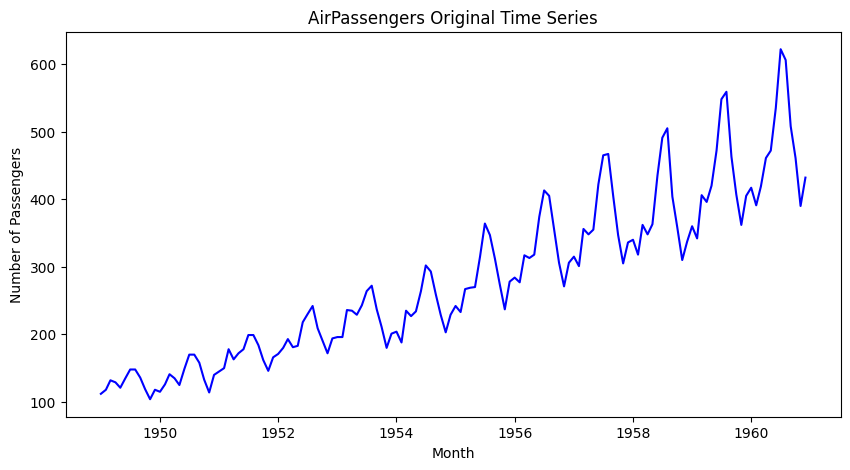

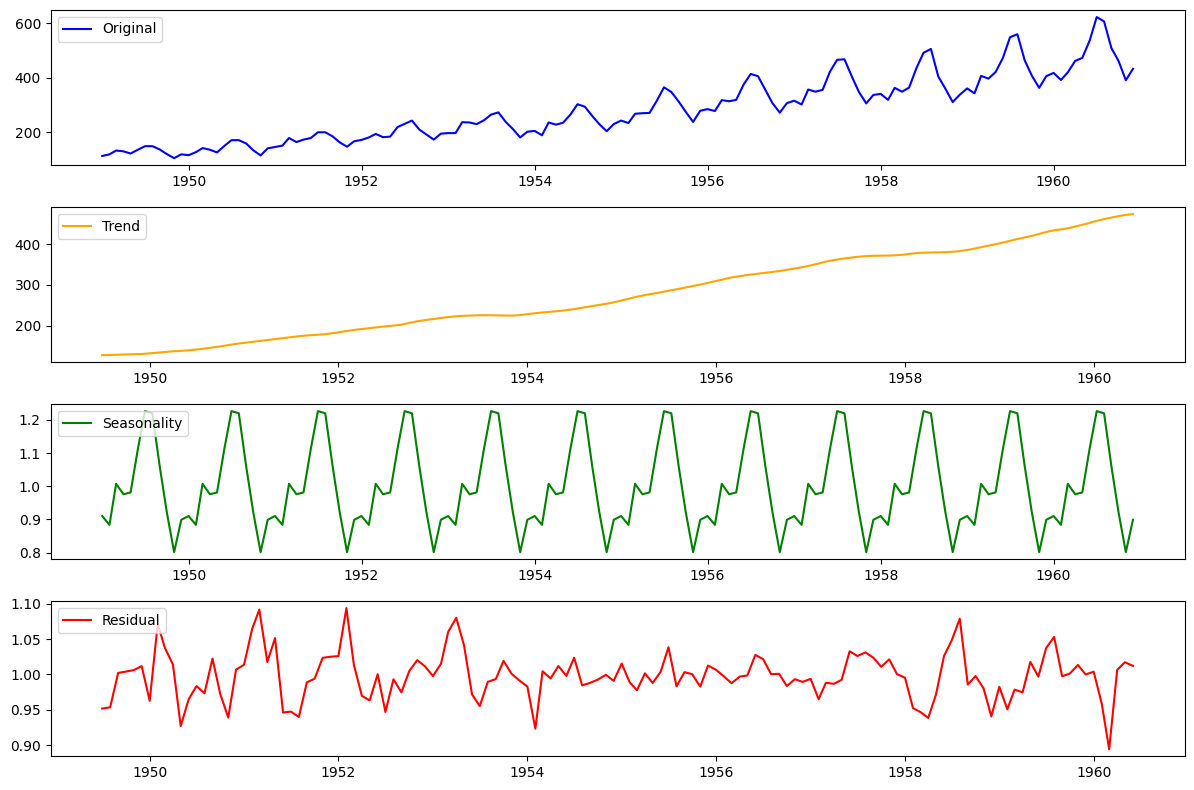

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load AirPassengers dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
data = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

# Plot original time series
plt.figure(figsize=(10,5))
plt.plot(data, color='blue')
plt.title('AirPassengers Original Time Series')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.show()

# Decompose time series
decomposition = seasonal_decompose(data, model='multiplicative')
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot decomposition
plt.figure(figsize=(12,8))
plt.subplot(411)
plt.plot(data, label='Original', color='blue')
plt.legend(loc='upper left')
plt.subplot(412)
plt.plot(trend, label='Trend', color='orange')
plt.legend(loc='upper left')
plt.subplot(413)
plt.plot(seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')
plt.subplot(414)
plt.plot(residual, label='Residual', color='red')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### **Q7.** Apply Isolation Forest on a numerical dataset (NYC Taxi Fare Data) to detect anomalies. Visualize the anomalies on a 2D scatter plot.
### **Answer:**
### We will use a sample of the NYC Taxi Fare dataset to detect anomalies using Isolation Forest and visualize them.

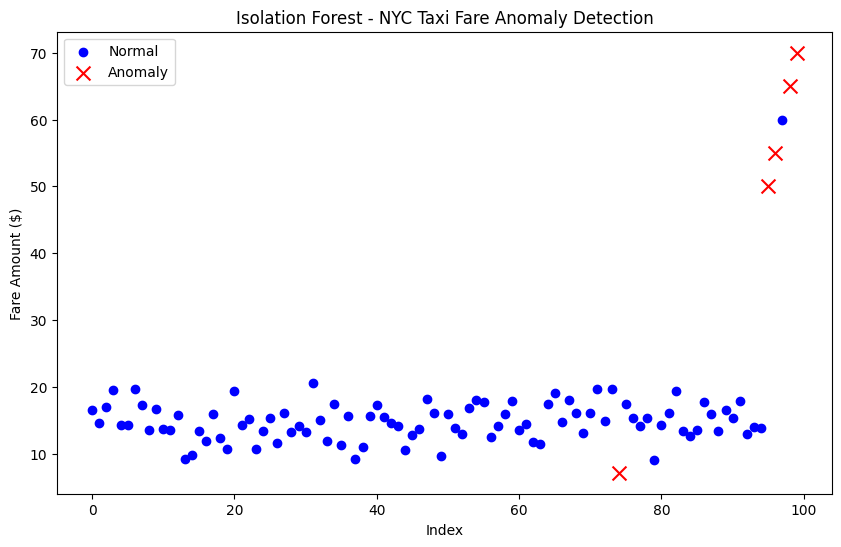

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Seed for reproducibility
np.random.seed(42)

# Sample NYC Taxi Fare dataset
nyc_data = pd.DataFrame({
    "pickup_datetime": pd.date_range(start="2020-01-01", periods=100, freq="D"),
    "fare_amount": np.random.normal(loc=15, scale=3, size=100)
})

# Introduce anomalies safely in the last 5 rows
nyc_data.iloc[-5:, nyc_data.columns.get_loc('fare_amount')] = [50, 55, 60, 65, 70]

# Apply Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
nyc_data['anomaly'] = iso_forest.fit_predict(nyc_data[['fare_amount']])

# Separate normal and anomalous points
normal = nyc_data[nyc_data['anomaly'] == 1]
anomalies = nyc_data[nyc_data['anomaly'] == -1]

# Plot the results
plt.figure(figsize=(10,6))
plt.scatter(normal.index, normal['fare_amount'], c='blue', label='Normal')
plt.scatter(anomalies.index, anomalies['fare_amount'], c='red', label='Anomaly', marker='x', s=100)
plt.title('Isolation Forest - NYC Taxi Fare Anomaly Detection')
plt.xlabel('Index')            # Corrected x-axis label
plt.ylabel('Fare Amount ($)')
plt.legend()
plt.show()

### **Q8.** Train a SARIMA model on the monthly airline passengers dataset (AirPassengers Dataset). Forecast the next 12 months and visualize the results.
### **Answer:**
### We will use the AirPassengers dataset (monthly international airline passengers, 1949–1960) to train a SARIMA model and forecast the next 12 months.

/tmp/ipykernel_18851/720661861.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  "Month": pd.date_range(start="1949-01-01", periods=144, freq="M"),
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/tmp/ipykernel_18851/720661861.py:40: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_index = pd.date_range(start=air_data.index[-1] + pd.offsets.MonthBegin(), periods=12, freq='M')


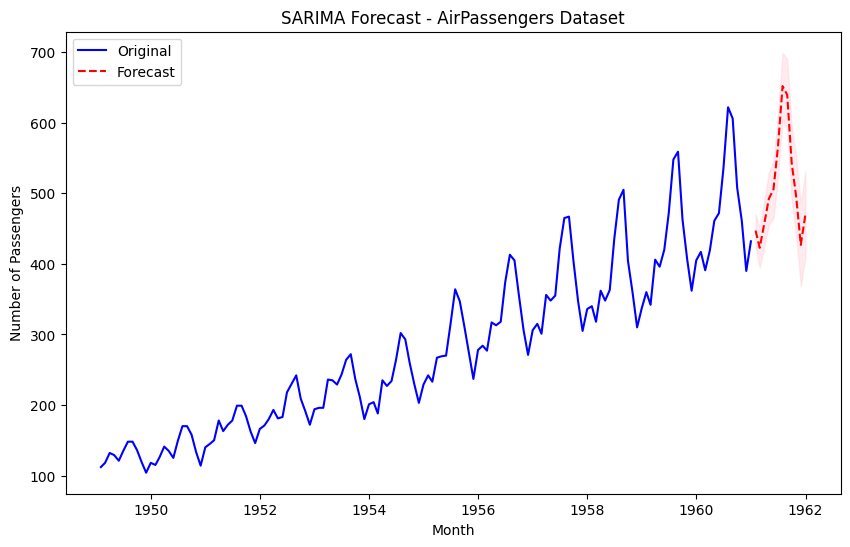

In [3]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# AirPassengers dataset included directly
data_dict = {
    "Month": pd.date_range(start="1949-01-01", periods=144, freq="M"),
    "Passengers": [
        112,118,132,129,121,135,148,148,136,119,104,118,
        115,126,141,135,125,149,170,170,158,133,114,140,
        145,150,178,163,172,178,199,199,184,162,146,166,
        171,180,193,181,183,218,230,242,209,191,172,194,
        196,196,236,235,229,243,264,272,237,211,180,201,
        204,188,235,227,234,264,302,293,259,229,203,229,
        242,233,267,269,270,315,364,347,312,274,237,278,
        284,277,317,313,318,374,413,405,355,306,271,306,
        315,301,356,348,355,422,465,467,404,347,305,336,
        340,318,362,348,363,435,491,505,404,359,310,337,
        360,342,406,396,420,472,548,559,463,407,362,405,
        417,391,419,461,472,535,622,606,508,461,390,432
    ]
}

# Convert to DataFrame
air_data = pd.DataFrame(data_dict)
air_data.set_index('Month', inplace=True)

# Train SARIMA model
# Here, (p,d,q) = (1,1,1) and seasonal (P,D,Q,s) = (1,1,1,12) as a simple example
sarima_model = SARIMAX(air_data['Passengers'],
                       order=(1,1,1),
                       seasonal_order=(1,1,1,12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# Forecast next 12 months
forecast = sarima_result.get_forecast(steps=12)
forecast_index = pd.date_range(start=air_data.index[-1] + pd.offsets.MonthBegin(), periods=12, freq='M')
forecast_series = pd.Series(forecast.predicted_mean.values, index=forecast_index)

# Plot original data and forecast
plt.figure(figsize=(10,6))
plt.plot(air_data['Passengers'], label='Original', color='blue')
plt.plot(forecast_series, label='Forecast', color='red', linestyle='--')
plt.fill_between(forecast_index, forecast.conf_int()['lower Passengers'], forecast.conf_int()['upper Passengers'],
                 color='pink', alpha=0.3)
plt.title('SARIMA Forecast - AirPassengers Dataset')
plt.xlabel('Month')
plt.ylabel('Number of Passengers')
plt.legend()
plt.show()

### **Q9.** Apply Local Outlier Factor (LOF) on a numerical dataset (NYC Taxi Fare Data) to detect anomalies and visualize them using matplotlib.
### **Answer:**
### We will use a sample of the NYC Taxi Fare dataset to detect anomalies using Local Outlier Factor (LOF) and visualize them on a scatter plot.

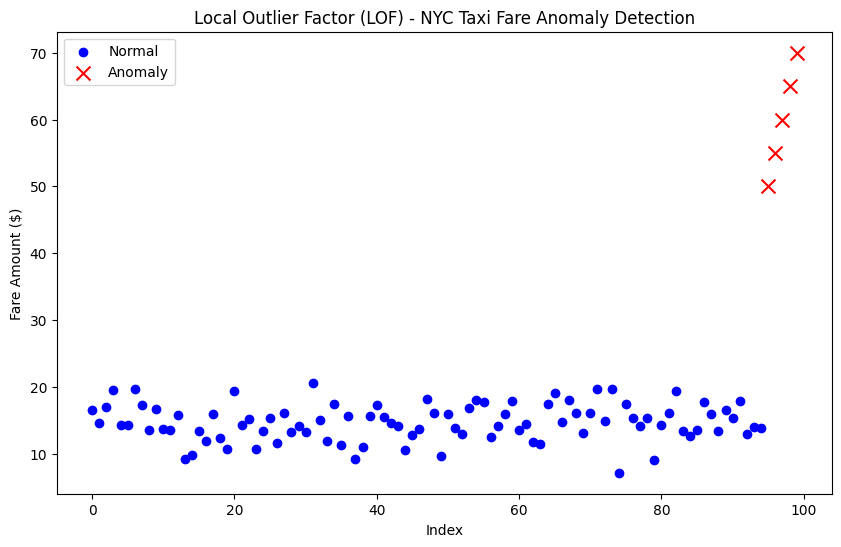

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import LocalOutlierFactor

# Seed for reproducibility
np.random.seed(42)

# Sample NYC Taxi Fare dataset
nyc_data = pd.DataFrame({
    "pickup_datetime": pd.date_range(start="2020-01-01", periods=100, freq="D"),
    "fare_amount": np.random.normal(loc=15, scale=3, size=100)
})

# Introduce anomalies safely in the last 5 rows
nyc_data.iloc[-5:, nyc_data.columns.get_loc('fare_amount')] = [50, 55, 60, 65, 70]

# Apply Local Outlier Factor
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
nyc_data['anomaly'] = lof.fit_predict(nyc_data[['fare_amount']])

# Separate normal and anomalous points
normal = nyc_data[nyc_data['anomaly'] == 1]
anomalies = nyc_data[nyc_data['anomaly'] == -1]

# Plot the results
plt.figure(figsize=(10,6))
plt.scatter(normal.index, normal['fare_amount'], c='blue', label='Normal')
plt.scatter(anomalies.index, anomalies['fare_amount'], c='red', label='Anomaly', marker='x', s=100)
plt.title('Local Outlier Factor (LOF) - NYC Taxi Fare Anomaly Detection')
plt.xlabel('Index')
plt.ylabel('Fare Amount ($)')
plt.legend()
plt.show()

### **Q10.** You are working as a data scientist for a power grid monitoring company. Your goal is to forecast energy demand and detect abnormal spikes or drops in real-time consumption data collected every 15 minutes. The dataset includes features like timestamp, region, weather conditions, and energy usage.

### **Explain your real-time data science workflow:**

### **1. Anomaly Detection:** How would you detect anomalies in this streaming data (Isolation Forest / LOF / DBSCAN)?
### **2. Time Series Forecasting:** Which time series model would you use for short-term forecasting (ARIMA / SARIMA / SARIMAX)?
### **3. Validation & Monitoring:** How would you validate and monitor the performance over time?
### **4. Business Impact:** How would this solution help business decisions or operations?
### **Dataset:** Power Grid Monitoring Data (timestamp, region, weather conditions, energy_usage)

### **Answer:**

### **1. Anomaly Detection in Streaming Data**
### Use Isolation Forest or Local Outlier Factor (LOF) on the energy_usage feature to detect abnormal spikes or drops.
### These algorithms are effective for real-time detection because they do not assume a specific distribution and can adapt to changing patterns in streaming data.
### **2. Time Series Forecasting**
### For short-term forecasting, use SARIMAX (or SARIMA) to capture trend, seasonality, and potential exogenous variables like weather conditions.
### SARIMAX allows including additional features (temperature, region) as exogenous regressors for more accurate forecasts.
### **3. Validation & Monitoring**
### Rolling forecast validation: Compare predicted vs. actual energy usage using metrics like RMSE, MAE, or MAPE.
### Anomaly monitoring: Track the frequency and magnitude of anomalies over time to detect sensor drift or operational issues.
### Dashboards & alerts: Integrate with real-time dashboards to notify operators of unusual spikes or drops.
### **4. Business Impact**
### Operations: Early detection of anomalies helps prevent overloads or blackouts.
### Resource Planning: Accurate short-term forecasts optimize energy distribution and reduce waste.
### Decision Support: Insights from anomaly patterns guide maintenance, resource allocation, and strategic planning for the power grid.

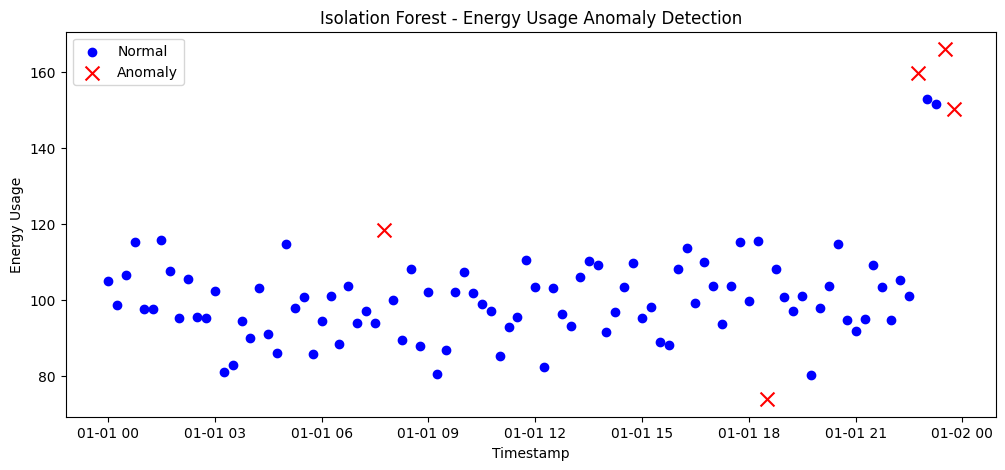

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


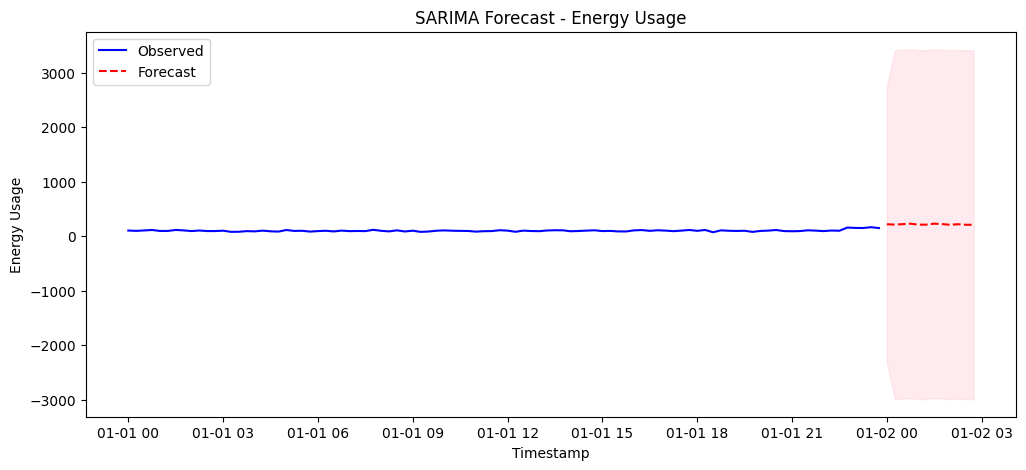

In [5]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from statsmodels.tsa.statespace.sarimax import SARIMAX

# -------------------------
# 1. Generate Sample Dataset
# -------------------------
np.random.seed(42)
timestamps = pd.date_range(start="2025-01-01", periods=96, freq="15min")  # 1 day of 15-min intervals
energy_usage = np.random.normal(loc=100, scale=10, size=96)  # Normal energy consumption
energy_usage[-5:] += [50, 60, 55, 70, 65]  # Introduce anomalies

grid_data = pd.DataFrame({
    "timestamp": timestamps,
    "energy_usage": energy_usage,
    "region": "Region_1",
    "temperature": np.random.normal(loc=25, scale=5, size=96)
})

# -------------------------
# 2. Anomaly Detection
# -------------------------
iso_forest = IsolationForest(contamination=0.05, random_state=42)
grid_data['anomaly'] = iso_forest.fit_predict(grid_data[['energy_usage']])

# Separate normal and anomalous points
normal = grid_data[grid_data['anomaly'] == 1]
anomalies = grid_data[grid_data['anomaly'] == -1]

# Plot anomalies
plt.figure(figsize=(12,5))
plt.scatter(normal['timestamp'], normal['energy_usage'], c='blue', label='Normal')
plt.scatter(anomalies['timestamp'], anomalies['energy_usage'], c='red', label='Anomaly', marker='x', s=100)
plt.title('Isolation Forest - Energy Usage Anomaly Detection')
plt.xlabel('Timestamp')
plt.ylabel('Energy Usage')
plt.legend()
plt.show()

# -------------------------
# 3. Short-Term Forecasting
# -------------------------
# Train SARIMA model (seasonal_periods=96 for daily seasonality in 15-min intervals)
sarima_model = SARIMAX(grid_data['energy_usage'],
                       order=(1,1,1),
                       seasonal_order=(1,1,1,96),
                       enforce_stationarity=False,
                       enforce_invertibility=False)
sarima_result = sarima_model.fit(disp=False)

# Forecast next 12 steps (3 hours ahead)
forecast = sarima_result.get_forecast(steps=12)
forecast_index = pd.date_range(start=grid_data['timestamp'].iloc[-1] + pd.Timedelta(minutes=15), periods=12, freq='15min')
forecast_series = pd.Series(forecast.predicted_mean.values, index=forecast_index)

# Plot forecast
plt.figure(figsize=(12,5))
plt.plot(grid_data['timestamp'], grid_data['energy_usage'], label='Observed', color='blue')
plt.plot(forecast_series, label='Forecast', color='red', linestyle='--')
plt.fill_between(forecast_index, forecast.conf_int()['lower energy_usage'], forecast.conf_int()['upper energy_usage'],
                 color='pink', alpha=0.3)
plt.title('SARIMA Forecast - Energy Usage')
plt.xlabel('Timestamp')
plt.ylabel('Energy Usage')
plt.legend()
plt.show()